In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from scipy.stats import shapiro, spearmanr, kruskal, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# ── Bonferroni-corrected alpha (11 hypotheses total: 6 faculty + 5 students)
N_HYPOTHESES  = 11
ALPHA_RAW     = 0.05
ALPHA_BONF    = ALPHA_RAW / N_HYPOTHESES          # 0.00455

# ── White-background publication style ───────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'axes.edgecolor'    : '#cccccc',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.color'        : '#eeeeee',
    'grid.linewidth'    : 0.8,
    'font.family'       : 'DejaVu Sans',
    'axes.titlesize'    : 12,
    'axes.labelsize'    : 10,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'legend.fontsize'   : 9,
    'legend.frameon'    : False,
})

PALETTE   = ['#2E86AB','#A23B72','#F18F01','#C73E1D','#3B1F2B','#44BBA4']
C_POS     = '#2E86AB'   # positive / primary
C_NEG     = '#C73E1D'   # negative / warning
C_NEUTRAL = '#888888'   # neutral

def sig_label(p, alpha_bonf=ALPHA_BONF):
    if p < alpha_bonf:
        return f'p={p:.4f} ✓ Significant (Bonferroni)'
    return f'p={p:.4f} ✗ Not significant (Bonferroni)'

def effect_r(r):
    r = abs(r)
    if r >= 0.5: return 'Large'
    if r >= 0.3: return 'Medium'
    if r >= 0.1: return 'Small'
    return 'Negligible'

print(f'Setup complete.  Bonferroni α = {ALPHA_BONF:.5f}  (α={ALPHA_RAW}/N={N_HYPOTHESES})')


Setup complete.  Bonferroni α = 0.00455  (α=0.05/N=11)


## PART 1 — FACULTY (ППС) SURVEY  |  N = 300

In [ ]:
# ── Load & clean ─────────────────────────────────────────────────────────────
df_raw_t = pd.read_csv('Report_T.csv', sep=';', skiprows=9, header=0)
df_t = df_raw_t.iloc[1:].copy().reset_index(drop=True)
ct   = df_t.columns

# ── Column aliases (confirmed by index) ──────────────────────────────────────
T_WIFI       = ct[20]   # Wi-Fi signal quality
T_CLOUD      = ct[22]   # M365 usage
T_STABILITY  = ct[25]   # Online-system stability
T_SKILL      = ct[29]   # Digital skill level
T_DIGITIZ    = ct[36]   # Digitization rating (1-10)
T_ALIGN      = ct[37]   # Alignment with educational goals
T_USABILITY  = ct[38]   # Tool usability
T_INTEG      = ct[45]   # System integration
T_INNOV      = ct[46]   # Innovation opportunities
T_PLATON     = ct[48]   # Platonus satisfaction (1-10)
T_SMART      = ct[51]   # SmartENU satisfaction (1-10)

def to_num(s): return pd.to_numeric(s, errors='coerce').dropna()

print(f'Faculty dataset: {df_t.shape[0]} respondents, {df_t.shape[1]} columns')


Faculty dataset: 300 respondents, 55 columns


### H1 (Faculty) — Digital Infrastructure Rating (threshold ≥ 6/10)
> **Test:** Descriptive statistics + One-sample t-test (H₀: μ = 6)

Shapiro-Wilk: W=0.926, p=0.0040  →  Non-normal distribution

H1 Faculty — One-Sample t-test (μ₀=6):
  Mean = 6.16  |  SD = 2.50
  95% CI = [5.88, 6.45]
  t = 1.132,  p=0.2587 ✗ Not significant (Bonferroni)
  Respondents rating ≥6: 63.0%


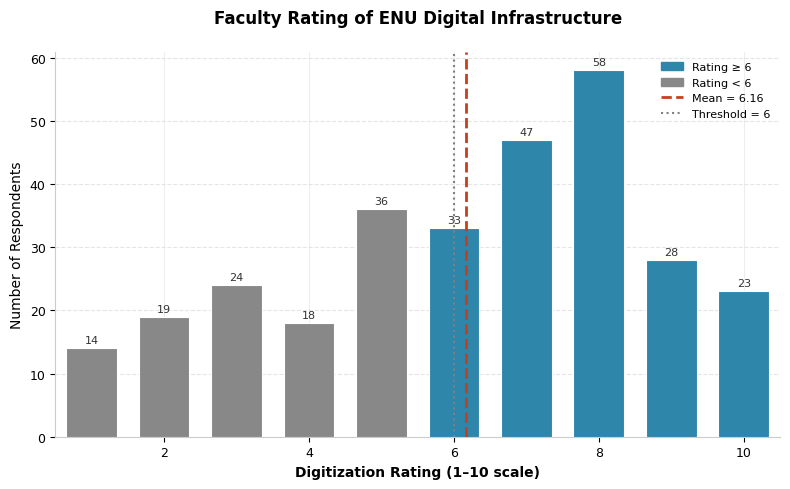

In [ ]:
# --- Есептеулер (өзгеріссіз қалды) ---
scores_t = to_num(df_t[T_DIGITIZ])

sw_stat, sw_p = shapiro(scores_t.sample(min(50, len(scores_t)), random_state=42))
print(f'Shapiro-Wilk: W={sw_stat:.3f}, p={sw_p:.4f}  →  '
      f'{"Normal" if sw_p > 0.05 else "Non-normal"} distribution')

t_stat, t_p = stats.ttest_1samp(scores_t, 6)
ci_low, ci_high = stats.t.interval(0.95, len(scores_t)-1,
                                    loc=scores_t.mean(),
                                    scale=stats.sem(scores_t))
pct_positive = (scores_t >= 6).mean() * 100

print(f'\nH1 Faculty — One-Sample t-test (μ₀=6):')
print(f'  Mean = {scores_t.mean():.2f}  |  SD = {scores_t.std():.2f}')
print(f'  95% CI = [{ci_low:.2f}, {ci_high:.2f}]')
print(f'  t = {t_stat:.3f},  {sig_label(t_p)}')
print(f'  Respondents rating ≥6: {pct_positive:.1f}%')

# ── Figure (График бөлімі) ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5), facecolor='white')

# ГРИДТЫ ТҮЗЕТУ (Осы жерде жазылуы керек):
ax.set_axisbelow(True) # Тор сызықтары бағандардың артында қалады
ax.grid(axis='y', linestyle='--', alpha=0.5, color='#cccccc', zorder=0)

counts_t = scores_t.value_counts().sort_index()
bars = ax.bar(counts_t.index, counts_t.values,
              color=[C_POS if x >= 6 else C_NEUTRAL for x in counts_t.index],
              width=0.7, edgecolor='white', linewidth=0.8, zorder=3) # zorder бағанды алға шығарады

# Басқа элементтер (өзгеріссіз):
ax.axvline(scores_t.mean(), color=C_NEG, linestyle='--', linewidth=2,
           label=f'Mean = {scores_t.mean():.2f} ', zorder=4)
ax.axvline(6, color='gray', linestyle=':', linewidth=1.5, label='Threshold = 6', zorder=4)

for bar, v in zip(bars, counts_t.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, str(v),
            ha='center', va='bottom', fontsize=8, color='#333333')

ax.set_xlabel('Digitization Rating (1–10 scale)', fontweight='bold')
ax.set_ylabel('Number of Respondents')
ax.set_title('Faculty Rating of ENU Digital Infrastructure\n' , fontweight='bold')

legend_patches = [mpatches.Patch(color=C_POS, label='Rating ≥ 6'),
                  mpatches.Patch(color=C_NEUTRAL, label='Rating < 6')]
ax.legend(handles=legend_patches + ax.get_lines()[:2], fontsize=8)
ax.set_xlim(0.5, 10.5)

plt.tight_layout()
plt.savefig('fig1_T_H1_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### H2 (Faculty) — Alignment of Digital Tools with Educational Goals
> **Test:** Descriptive proportions + Chi-square goodness-of-fit

In [ ]:
ALIGN_MAP_T = {
    'В полной мере соответствуют' : ('Fully Aligned',        4),
    'Скорее соответствуют'        : ('Mostly Aligned',       3),
    'Затрудняюсь ответить'        : ('Uncertain',            2),
    'Скорее не соответствуют'     : ('Mostly Not Aligned',   1),
    'Совершенно не соответствуют' : ('Not Aligned',          0),
}
align_raw_t  = df_t[T_ALIGN].dropna().apply(lambda x: str(x).strip())
align_label  = align_raw_t.map(lambda x: ALIGN_MAP_T.get(x, (x, np.nan))[0])
align_counts = align_label.value_counts()

# Order for display
order = ['Fully Aligned', 'Mostly Aligned', 'Uncertain',
         'Mostly Not Aligned', 'Not Aligned']
align_counts = align_counts.reindex(order).dropna()

positive_pct = (align_counts[['Fully Aligned','Mostly Aligned']].sum()
                / align_counts.sum() * 100)

# Chi-square against uniform expected distribution
chi2, chi_p = stats.chisquare(align_counts.values)
print(f'H2 Faculty — Alignment Chi-square:')
print(f'  χ² = {chi2:.2f}, {sig_label(chi_p)}')
print(f'  Positive alignment (Fully + Mostly): {positive_pct:.1f}%')

H2 Faculty — Alignment Chi-square:
  χ² = 239.57, p=0.0000 ✓ Significant (Bonferroni)
  Positive alignment (Fully + Mostly): 69.7%


In [ ]:
USAB_MAP_T = {
    'Инструменты легки в использовании, легко осваиваются и комфортны' : 'Easy & Comfortable',
    'Работать с ними очень удобно и просто'                             : 'Very Convenient',
    'Есть некоторые сложности, с которыми сталкиваешься в работе'      : 'Some Difficulties',
    'Работать с ними по большей части неудобно, слишком сложно'        : 'Mostly Inconvenient',
    'Затрудняюсь ответить'                                             : 'Uncertain',
}
usab_raw_t   = df_t[T_USABILITY].dropna().apply(lambda x: str(x).strip())
usab_label   = usab_raw_t.map(lambda x: USAB_MAP_T.get(x, x))
usab_counts  = usab_label.value_counts()
usab_order   = ['Easy & Comfortable','Very Convenient','Some Difficulties',
                'Mostly Inconvenient','Uncertain']
usab_counts  = usab_counts.reindex(usab_order).dropna()
usab_colors  = ['#2E86AB','#44BBA4','#F18F01','#C73E1D','#cccccc']

pos_usab_pct = usab_counts[['Easy & Comfortable','Very Convenient']].sum() / usab_counts.sum() * 100

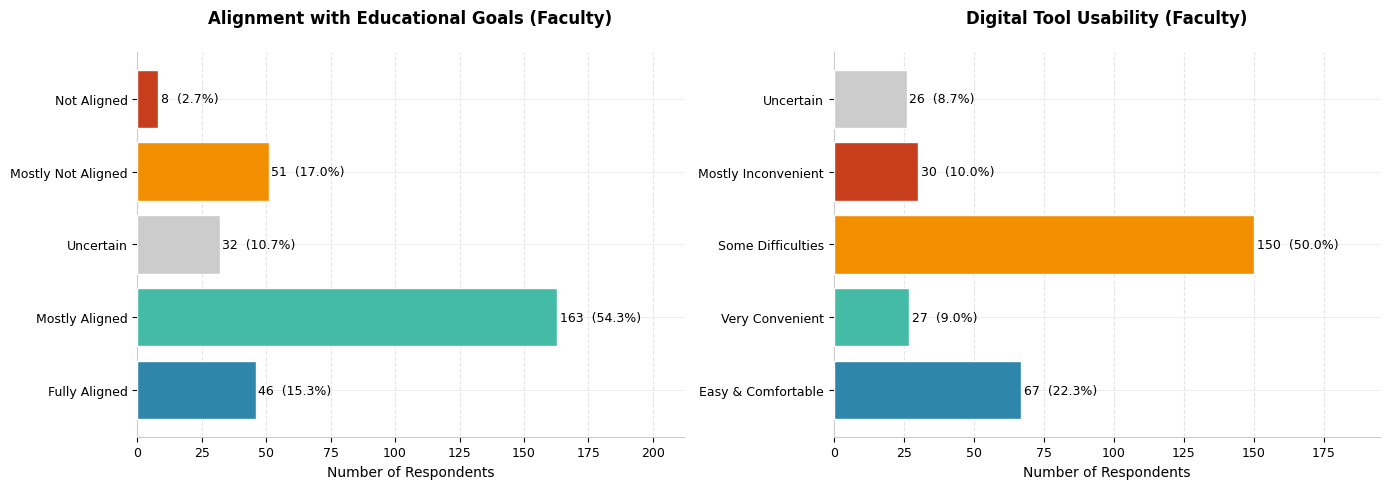

In [ ]:
# --- Есептеулер (өзгеріссіз) ---
align_raw_t  = df_t[T_ALIGN].dropna().apply(lambda x: str(x).strip())
align_label  = align_raw_t.map(lambda x: ALIGN_MAP_T.get(x, (x, np.nan))[0])
align_counts = align_label.value_counts()
order = ['Fully Aligned', 'Mostly Aligned', 'Uncertain', 'Mostly Not Aligned', 'Not Aligned']
align_counts = align_counts.reindex(order).dropna()

# --- Figure басталуы ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

# --- ГРИДТЫ ТҮЗЕТУ (Екі график үшін) ---
for ax in axes:
    ax.set_axisbelow(True) # Грид бағандардың артында тұрады
    ax.grid(axis='x', linestyle='--', alpha=0.5, color='#cccccc', zorder=0)

# --- 1-ші график: Alignment ---
colors_align = ['#2E86AB','#44BBA4','#cccccc','#F18F01','#C73E1D']
bars2 = axes[0].barh(align_counts.index, align_counts.values,
                     color=colors_align[:len(align_counts)], edgecolor='white', zorder=3)

for bar, v in zip(bars2, align_counts.values):
    axes[0].text(v + 1, bar.get_y() + bar.get_height()/2,
                 f'{v}  ({v/align_counts.sum()*100:.1f}%)',
                 va='center', fontsize=9)
axes[0].set_xlabel('Number of Respondents')
axes[0].set_title(f'Alignment with Educational Goals (Faculty)\n'
                  ,
                  fontweight='bold')
axes[0].set_xlim(0, align_counts.max() * 1.3)

# --- 2-ші график: Usability ---
# ... (usab_counts есептеулері өзгеріссіз) ...
bars3 = axes[1].barh(usab_counts.index, usab_counts.values,
                     color=usab_colors[:len(usab_counts)], edgecolor='white', zorder=3)

for bar, v in zip(bars3, usab_counts.values):
    axes[1].text(v + 1, bar.get_y() + bar.get_height()/2,
                 f'{v}  ({v/usab_counts.sum()*100:.1f}%)', va='center', fontsize=9)

axes[1].set_xlabel('Number of Respondents')
axes[1].set_title(f'Digital Tool Usability (Faculty)\n'
                ,
                  fontweight='bold')
axes[1].set_xlim(0, usab_counts.max() * 1.3)

plt.tight_layout()
plt.savefig('fig2_T_H2_alignment_usability.png', dpi=300, bbox_inches='tight')
plt.show()

### H3 (Faculty) — Digital Skill Level ↔ Digitization Rating
> **Tests:** Kruskal-Wallis H (group difference) + Spearman ρ (monotonic trend)  
> *Rationale: Skill level is ordinal → Spearman/Kruskal preferred over Pearson/ANOVA*

In [ ]:
SKILL_MAP_T = {
    'Начинающий'   : 1, 'Базовый'     : 2, 'Средний'    : 3,
    'Продвинутый'  : 4, 'Экспертный'  : 5,
}
def get_skill(s):
    s = str(s)
    for k, v in SKILL_MAP_T.items():
        if k in s: return v
    return np.nan

df_t['skill_num'] = df_t[T_SKILL].apply(get_skill)
df_t['dig_score'] = pd.to_numeric(df_t[T_DIGITIZ], errors='coerce')
h3_t = df_t[['skill_num','dig_score']].dropna()

# Kruskal-Wallis H test
groups_kw = [h3_t.loc[h3_t['skill_num']==k,'dig_score'].values
             for k in sorted(h3_t['skill_num'].unique())]
kw_h, kw_p = kruskal(*groups_kw)

# Spearman rho
rho3, p3 = spearmanr(h3_t['skill_num'], h3_t['dig_score'])
r2_3 = rho3**2  # effect size (variance explained)

print('H3 Faculty — Digital Skill Level ↔ Digitization Rating')
print(f'  Kruskal-Wallis: H={kw_h:.3f}, {sig_label(kw_p)}')
print(f'  Spearman ρ = {rho3:.3f},  ρ² = {r2_3:.3f} ({effect_r(rho3)} effect)')
print(f'  {sig_label(p3)}')

SKILL_LBL = {1:'Beginner',2:'Basic',3:'Intermediate',4:'Advanced',5:'Expert'}
group_means_t = h3_t.groupby('skill_num')['dig_score'].mean()
group_n_t     = h3_t.groupby('skill_num')['dig_score'].count()



H3 Faculty — Digital Skill Level ↔ Digitization Rating
  Kruskal-Wallis: H=4.248, p=0.3735 ✗ Not significant (Bonferroni)
  Spearman ρ = 0.095,  ρ² = 0.009 (Negligible effect)
  p=0.1085 ✗ Not significant (Bonferroni)


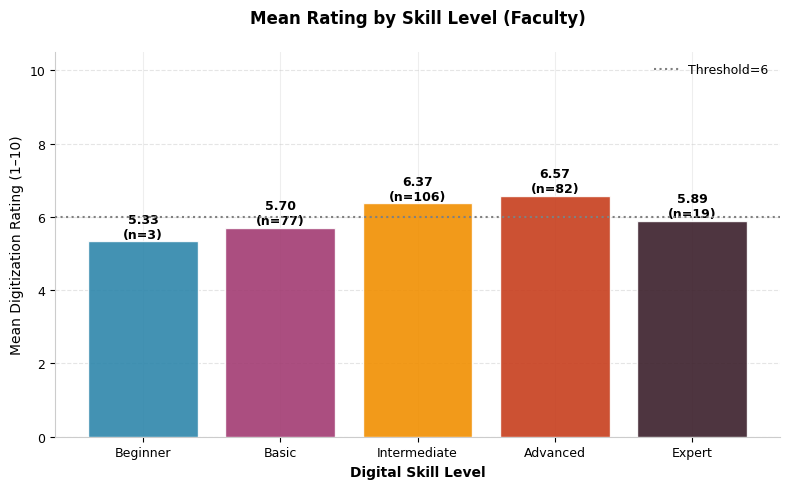

In [ ]:
# ── Figure 3a (Bar Chart) ───────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 5), facecolor='white')

# ГРИДТЫ ТҮЗЕТУ
ax1.set_axisbelow(True)
ax1.grid(axis='y', linestyle='--', alpha=0.5, color='#cccccc', zorder=0)

x_lbls = [SKILL_LBL[i] for i in group_means_t.index]
bars = ax1.bar(x_lbls, group_means_t.values,
               color=PALETTE[:len(group_means_t)], edgecolor='white', alpha=0.9, zorder=3)

for bar, v, n in zip(bars, group_means_t.values, group_n_t.values):
    ax1.text(bar.get_x()+bar.get_width()/2, v+0.1, f'{v:.2f}\n(n={n})',
             ha='center', fontsize=9, fontweight='bold')

ax1.axhline(6, color='gray', linestyle=':', linewidth=1.5, label='Threshold=6', zorder=4)
ax1.set_ylim(0, 10.5)
ax1.set_xlabel('Digital Skill Level', fontweight='bold')
ax1.set_ylabel('Mean Digitization Rating (1–10)')
ax1.set_title(f'Mean Rating by Skill Level (Faculty)\n', fontweight='bold')
ax1.legend()

plt.tight_layout()
plt.savefig('fig3a_mean_rating.png', dpi=300, bbox_inches='tight')
plt.show()

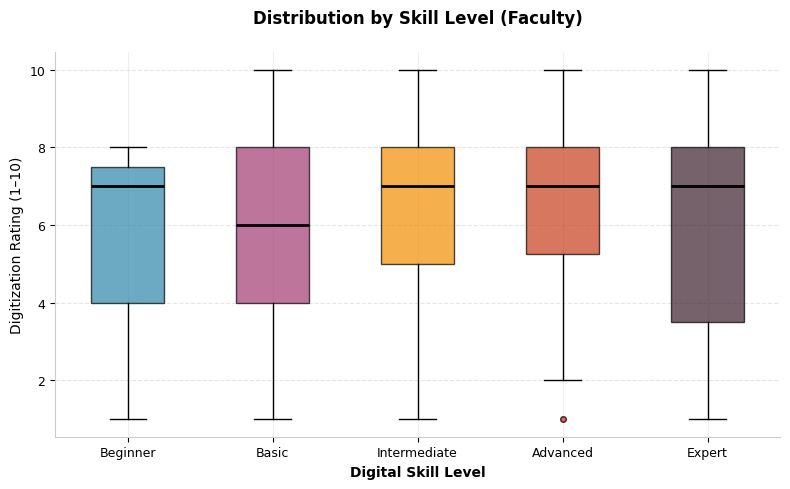

In [ ]:
# ── Figure 3b (Boxplot) ─────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 5), facecolor='white')

# ГРИДТЫ ТҮЗЕТУ
ax2.set_axisbelow(True)
ax2.grid(axis='y', linestyle='--', alpha=0.5, color='#cccccc', zorder=0)

bp = ax2.boxplot(groups_kw, patch_artist=True, tick_labels=x_lbls,
                 medianprops=dict(color='black', linewidth=2),
                 flierprops=dict(marker='o', markerfacecolor=C_NEG,
                                 markersize=4, alpha=0.5), zorder=3)

for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_xlabel('Digital Skill Level', fontweight='bold')
ax2.set_ylabel('Digitization Rating (1–10)')
ax2.set_title(f'Distribution by Skill Level (Faculty)\n', fontweight='bold')

plt.tight_layout()
plt.savefig('fig3b_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

### H4 (Faculty) — Wi-Fi Quality ↔ Online System Stability
> **Test:** Spearman ρ (ordinal ↔ ordinal)

In [ ]:
WIFI_MAP = {'Плохой':1,'Удовлетворительный':2,'Хороший':3,'Отличный':4}
STAB_MAP = {'Плохая':1,'Удовлетворительная':2,'Хорошая':3,'Отличная':4}

def apply_map(series, mapping):
    return series.apply(lambda x: next((v for k,v in mapping.items() if k in str(x)), np.nan))

df_t['wifi_num'] = apply_map(df_t[T_WIFI], WIFI_MAP)
df_t['stab_num'] = apply_map(df_t[T_STABILITY], STAB_MAP)
h4_t = df_t[['wifi_num','stab_num']].dropna()

rho4, p4 = spearmanr(h4_t['wifi_num'], h4_t['stab_num'])
r2_4 = rho4**2

print('H4 Faculty — Wi-Fi Quality ↔ System Stability')
print(f'  Spearman ρ = {rho4:.3f},  ρ² = {r2_4:.3f} ({effect_r(rho4)} effect)')
print(f'  {sig_label(p4)}  |  N = {len(h4_t)}')

WIFI_LBL = {1:'Poor',2:'Satisfactory',3:'Good',4:'Excellent'}
STAB_LBL = {1:'Poor',2:'Satisfactory',3:'Good',4:'Excellent'}

H4 Faculty — Wi-Fi Quality ↔ System Stability
  Spearman ρ = 0.312,  ρ² = 0.097 (Medium effect)
  p=0.0000 ✓ Significant (Bonferroni)  |  N = 293


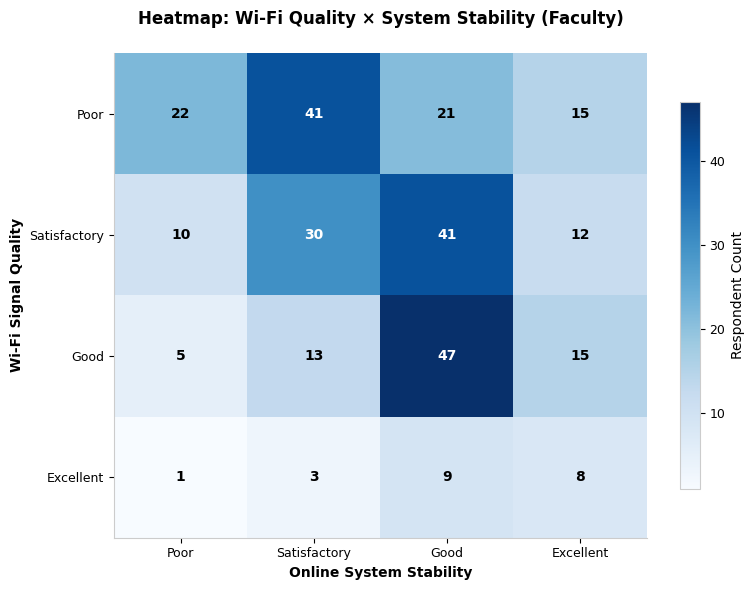

In [ ]:
# ── Figure 4a (Heatmap) ──────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 6), facecolor='white')

ct4 = pd.crosstab(h4_t['wifi_num'], h4_t['stab_num'])
im = ax1.imshow(ct4.values, cmap='Blues', aspect='auto')

# Түстік шкала (Colorbar)
plt.colorbar(im, ax=ax1, shrink=0.8, label='Respondent Count')

# Осьтердің белгілері
ax1.set_xticks(range(len(ct4.columns)))
ax1.set_xticklabels([STAB_LBL.get(c,'?') for c in ct4.columns])
ax1.set_yticks(range(len(ct4.index)))
ax1.set_yticklabels([WIFI_LBL.get(r,'?') for r in ct4.index])

ax1.set_xlabel('Online System Stability', fontweight='bold')
ax1.set_ylabel('Wi-Fi Signal Quality', fontweight='bold')

# Ұяшық ішіндегі сандар
for i in range(ct4.shape[0]):
    for j in range(ct4.shape[1]):
        clr = 'white' if ct4.values[i,j] > ct4.values.max()/2 else 'black'
        ax1.text(j, i, ct4.values[i,j], ha='center', va='center',
                 fontweight='bold', color=clr, fontsize=10)

ax1.set_title(f'Heatmap: Wi-Fi Quality × System Stability (Faculty)\n', fontweight='bold')

ax1.grid(False) # Heatmap үшін гридті өшіру (дұрыс көрінуі үшін)

plt.tight_layout()
plt.savefig('fig4a_heatmap_wifi.png', dpi=300, bbox_inches='tight')
plt.show()

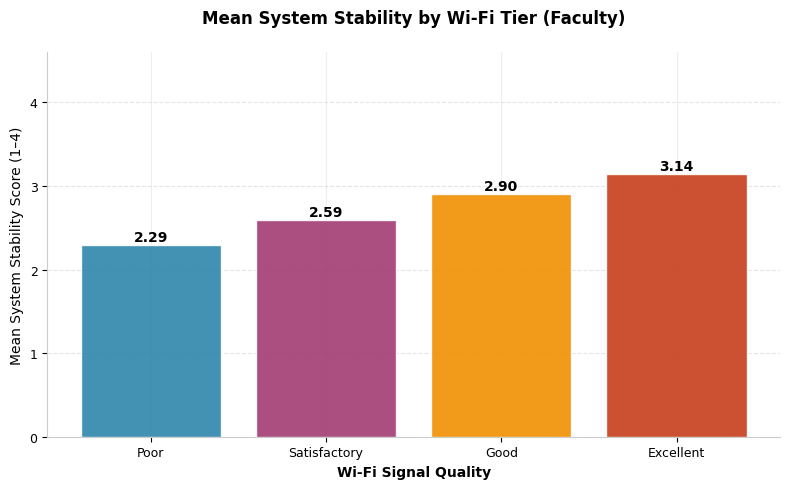

In [ ]:
# ── Figure 4b (Mean Stability Bar Chart) ─────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 5), facecolor='white')

# ГРИДТЫ ТҮЗЕТУ
ax2.set_axisbelow(True)
ax2.grid(axis='y', linestyle='--', alpha=0.5, color='#cccccc', zorder=0)

grp4 = h4_t.groupby('wifi_num')['stab_num'].mean()
x_lbls4 = [WIFI_LBL.get(k,'?') for k in grp4.index]

bars4 = ax2.bar(x_lbls4, grp4.values, color=PALETTE[:len(grp4)],
                edgecolor='white', alpha=0.9, zorder=3)

for bar, v in zip(bars4, grp4.values):
    ax2.text(bar.get_x()+bar.get_width()/2, v+0.05, f'{v:.2f}',
             ha='center', fontsize=10, fontweight='bold')

ax2.set_ylim(0, 4.6)
ax2.set_xlabel('Wi-Fi Signal Quality', fontweight='bold')
ax2.set_ylabel('Mean System Stability Score (1–4)')
ax2.set_title(f'Mean System Stability by Wi-Fi Tier (Faculty)\n', fontweight='bold')

plt.tight_layout()
plt.savefig('fig4b_mean_stability.png', dpi=300, bbox_inches='tight')
plt.show()

### H5 (Faculty) — Microsoft 365 Usage ↔ AIS Satisfaction
> **Test:** Spearman ρ (ordinal cloud usage ↔ continuous satisfaction score)

In [ ]:
CLOUD_MAP = {'нет':0,'редко':1,'иногда':2,'активно':3}
def get_cloud(s):
    s = str(s).lower()
    for k, v in CLOUD_MAP.items():
        if k in s: return v
    return np.nan

df_t['cloud_num']  = df_t[T_CLOUD].apply(get_cloud)
df_t['platon_sat'] = pd.to_numeric(df_t[T_PLATON], errors='coerce')
df_t['smart_sat']  = pd.to_numeric(df_t[T_SMART],  errors='coerce')
h5_t = df_t[['cloud_num','platon_sat','smart_sat']].dropna()

rho5_pl, p5_pl = spearmanr(h5_t['cloud_num'], h5_t['platon_sat'])
rho5_sm, p5_sm = spearmanr(h5_t['cloud_num'], h5_t['smart_sat'])

print('H5 Faculty — M365 Usage ↔ AIS Satisfaction')
print(f'  Platonus:  Spearman ρ={rho5_pl:.3f}, ρ²={rho5_pl**2:.3f}, '
      f'Effect={effect_r(rho5_pl)}, {sig_label(p5_pl)}')
print(f'  SmartENU:  Spearman ρ={rho5_sm:.3f}, ρ²={rho5_sm**2:.3f}, '
      f'Effect={effect_r(rho5_sm)}, {sig_label(p5_sm)}')

CLOUD_LBL = {0:'Never',1:'Rarely',2:'Occasionally',3:'Actively'}

H5 Faculty — M365 Usage ↔ AIS Satisfaction
  Platonus:  Spearman ρ=0.128, ρ²=0.016, Effect=Small, p=0.0264 ✗ Not significant (Bonferroni)
  SmartENU:  Spearman ρ=0.156, ρ²=0.024, Effect=Small, p=0.0069 ✗ Not significant (Bonferroni)


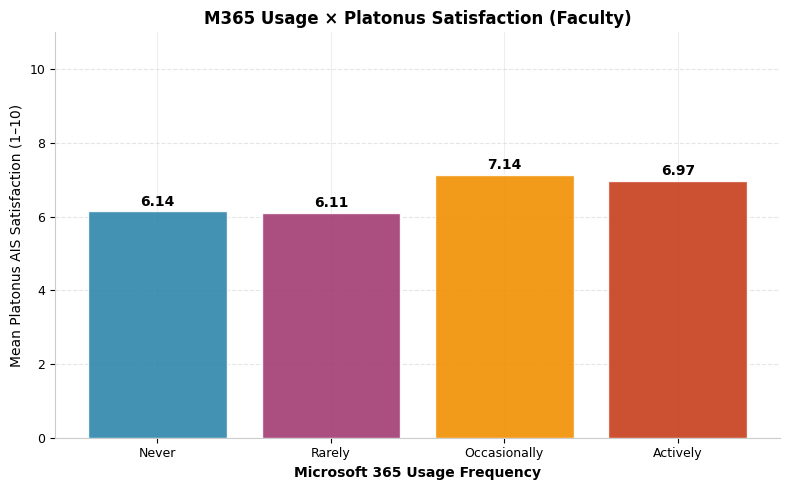

In [ ]:
# ── Figure 5a (Platonus Satisfaction) ───────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 5), facecolor='white')

# ГРИДТЫ ТҮЗЕТУ
ax1.set_axisbelow(True)
ax1.grid(axis='y', linestyle='--', alpha=0.5, color='#cccccc', zorder=0)

grp_pl = h5_t.groupby('cloud_num')['platon_sat'].mean()
x_l_pl = [CLOUD_LBL.get(k,'?') for k in grp_pl.index]

bars1 = ax1.bar(x_l_pl, grp_pl.values, color=PALETTE[:len(grp_pl)],
                edgecolor='white', alpha=0.9, zorder=3)

for bar, v in zip(bars1, grp_pl.values):
    ax1.text(bar.get_x()+bar.get_width()/2, v+0.15, f'{v:.2f}',
             ha='center', fontsize=10, fontweight='bold')

ax1.set_ylim(0, 11)
ax1.set_xlabel('Microsoft 365 Usage Frequency', fontweight='bold')
ax1.set_ylabel('Mean Platonus AIS Satisfaction (1–10)')
ax1.set_title(f'M365 Usage × Platonus Satisfaction (Faculty)', fontweight='bold')

plt.tight_layout()
plt.savefig('fig5a_platonus_sat.png', dpi=300, bbox_inches='tight')
plt.show()

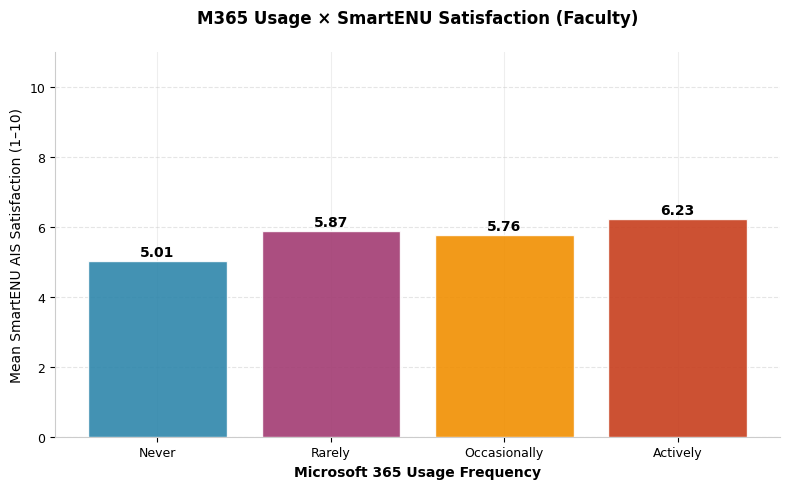

In [ ]:
# ── Figure 5b (SmartENU Satisfaction) ───────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 5), facecolor='white')

# ГРИДТЫ ТҮЗЕТУ
ax2.set_axisbelow(True)
ax2.grid(axis='y', linestyle='--', alpha=0.5, color='#cccccc', zorder=0)

grp_sm = h5_t.groupby('cloud_num')['smart_sat'].mean()
x_l_sm = [CLOUD_LBL.get(k,'?') for k in grp_sm.index]

bars2 = ax2.bar(x_l_sm, grp_sm.values, color=PALETTE[:len(grp_sm)],
                edgecolor='white', alpha=0.9, zorder=3)

for bar, v in zip(bars2, grp_sm.values):
    ax2.text(bar.get_x()+bar.get_width()/2, v+0.15, f'{v:.2f}',
             ha='center', fontsize=10, fontweight='bold')

ax2.set_ylim(0, 11)
ax2.set_xlabel('Microsoft 365 Usage Frequency', fontweight='bold')
ax2.set_ylabel('Mean SmartENU AIS Satisfaction (1–10)')
ax2.set_title(f'M365 Usage × SmartENU Satisfaction (Faculty)\n', fontweight='bold')

plt.tight_layout()
plt.savefig('fig5b_smartenu_sat.png', dpi=300, bbox_inches='tight')
plt.show()

### H6 (Faculty) — System Integration ↔ Innovation Opportunities
> **Test:** Spearman ρ (ordinal ↔ ordinal)

In [ ]:
INTEG_MAP = {'Полностью':4,'Хорошо':3,'Ограниченно':2,'Практически не':1,'Затрудняюсь':0}
INNOV_MAP  = {'полной':3,'частично':2,'Не предоставл':1,'Затрудняюсь':0}

def get_integ(s):
    s = str(s)
    for k, v in INTEG_MAP.items():
        if k in s: return v
    return np.nan

def get_innov(s):
    s = str(s)
    for k, v in INNOV_MAP.items():
        if k in s: return v
    return np.nan

df_t['integ_num'] = df_t[T_INTEG].apply(get_integ)
df_t['innov_num'] = df_t[T_INNOV].apply(get_innov)
h6_t = df_t[['integ_num','innov_num']].dropna()

rho6, p6 = spearmanr(h6_t['integ_num'], h6_t['innov_num'])
r2_6 = rho6**2

print('H6 Faculty — System Integration ↔ Innovation Opportunities')
print(f'  Spearman ρ = {rho6:.3f},  ρ² = {r2_6:.3f} ({effect_r(rho6)} effect)')
print(f'  {sig_label(p6)}  |  N = {len(h6_t)}')

INTEG_LBL = {0:'N/A',1:'None',2:'Limited',3:'Good',4:'Full'}
INNOV_LBL  = {0:'N/A',1:'None',2:'Partial',3:'Full'}


H6 Faculty — System Integration ↔ Innovation Opportunities
  Spearman ρ = 0.233,  ρ² = 0.054 (Small effect)
  p=0.0000 ✓ Significant (Bonferroni)  |  N = 300


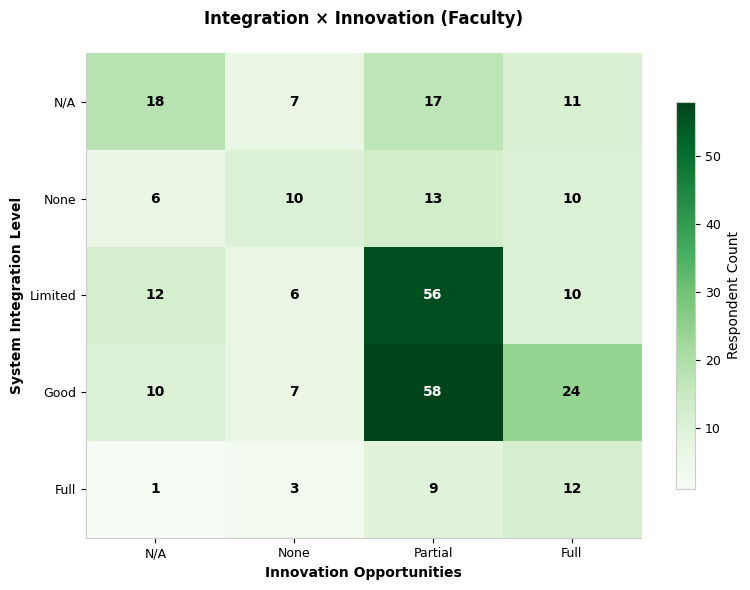

In [ ]:
# ── Figure 6a (Heatmap: Integration × Innovation) ───────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 6), facecolor='white')

ct6 = pd.crosstab(h6_t['integ_num'], h6_t['innov_num'])
im6 = ax1.imshow(ct6.values, cmap='Greens', aspect='auto')

# Түстік шкала
plt.colorbar(im6, ax=ax1, shrink=0.8, label='Respondent Count')

# Осьтердің белгілері
ax1.set_xticks(range(len(ct6.columns)))
ax1.set_xticklabels([INNOV_LBL.get(c,'?') for c in ct6.columns])
ax1.set_yticks(range(len(ct6.index)))
ax1.set_yticklabels([INTEG_LBL.get(r,'?') for r in ct6.index])

ax1.set_xlabel('Innovation Opportunities', fontweight='bold')
ax1.set_ylabel('System Integration Level', fontweight='bold')

# Ұяшықтардағы сандар
for i in range(ct6.shape[0]):
    for j in range(ct6.shape[1]):
        clr = 'white' if ct6.values[i,j] > ct6.values.max()/2 else 'black'
        ax1.text(j, i, ct6.values[i,j], ha='center', va='center',
                 fontweight='bold', color=clr, fontsize=10)

ax1.set_title(f'Integration × Innovation (Faculty)\n', fontweight='bold')

# Heatmap-те тор сызықтары қажет емес
ax1.grid(False)

plt.tight_layout()
plt.savefig('fig6a_heatmap_integration.png', dpi=300, bbox_inches='tight')
plt.show()

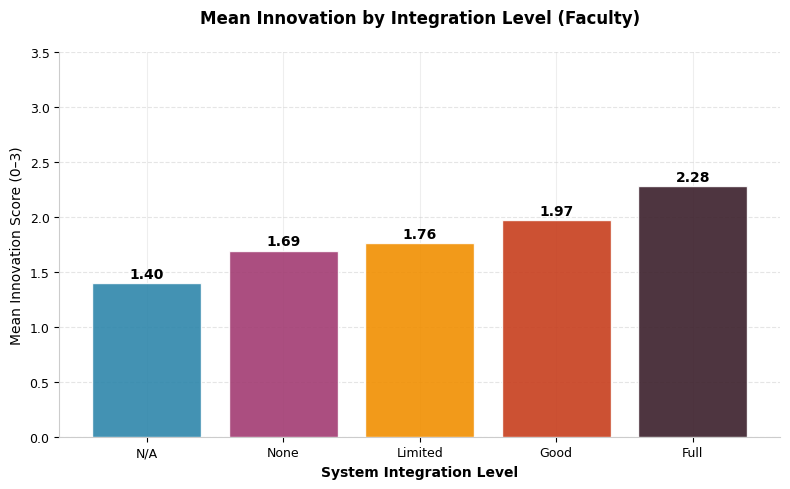

In [ ]:
# ── Figure 6b (Mean Innovation Bar Chart) ──────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 5), facecolor='white')

# ГРИДТЫ ТҮЗЕТУ
ax2.set_axisbelow(True) # Тор бағандардың артында қалады
ax2.grid(axis='y', linestyle='--', alpha=0.5, color='#cccccc', zorder=0)

grp6 = h6_t.groupby('integ_num')['innov_num'].mean()
x_l6 = [INTEG_LBL.get(k,'?') for k in grp6.index]

bars6 = ax2.bar(x_l6, grp6.values, color=PALETTE[:len(grp6)],
                edgecolor='white', alpha=0.9, zorder=3)

for bar, v in zip(bars6, grp6.values):
    ax2.text(bar.get_x()+bar.get_width()/2, v+0.05, f'{v:.2f}',
             ha='center', fontsize=10, fontweight='bold')

ax2.set_ylim(0, 3.5)
ax2.set_xlabel('System Integration Level', fontweight='bold')
ax2.set_ylabel('Mean Innovation Score (0–3)')
ax2.set_title(f'Mean Innovation by Integration Level (Faculty)\n', fontweight='bold')

plt.tight_layout()
plt.savefig('fig6b_mean_innovation.png', dpi=300, bbox_inches='tight')
plt.show()

---
## PART 2 — STUDENT SURVEY  |  N = 1,230

In [ ]:
df_raw_s = pd.read_csv('Report_S.csv', sep=';', skiprows=9, header=0)
df_s = df_raw_s.iloc[1:].copy().reset_index(drop=True)
cs   = df_s.columns

S_COURSE    = cs[6]
S_WIFI      = cs[15]
S_CLOUD     = cs[17]
S_STABILITY = cs[20]
S_SKILL     = cs[24]
S_DIGITIZ   = cs[31]
S_ALIGN     = cs[32]
S_USABILITY = cs[33]
S_PLATON    = cs[43]
S_SMART     = cs[46]

print(f'Student dataset: {df_s.shape[0]} respondents, {df_s.shape[1]} columns')


Student dataset: 1230 respondents, 50 columns


### H1 (Students) — Digital Infrastructure Rating (threshold ≥ 6/10)
> **Test:** Descriptive statistics + One-sample t-test (H₀: μ = 6)

In [ ]:
# --- Есептеулер бөлімі (өзгеріссіз) ---
scores_s = to_num(df_s[S_DIGITIZ])

t_stat_s, t_p_s = stats.ttest_1samp(scores_s, 6)
ci_s = stats.t.interval(0.95, len(scores_s)-1,
                        loc=scores_s.mean(), scale=stats.sem(scores_s))
pct_pos_s = (scores_s >= 6).mean() * 100

print('H1 Students — One-Sample t-test (μ₀=6):')
print(f'  Mean = {scores_s.mean():.2f}  |  SD = {scores_s.std():.2f}')
print(f'  95% CI = [{ci_s[0]:.2f}, {ci_s[1]:.2f}]')
print(f'  t({len(scores_s)-1}) = {t_stat_s:.3f},  {sig_label(t_p_s)}')
print(f'  Respondents rating ≥6: {pct_pos_s:.1f}%')


H1 Students — One-Sample t-test (μ₀=6):
  Mean = 6.90  |  SD = 2.45
  95% CI = [6.76, 7.03]
  t(1229) = 12.789,  p=0.0000 ✓ Significant (Bonferroni)
  Respondents rating ≥6: 75.1%


H1 Students — One-Sample t-test (μ₀=6):
  Mean = 6.90  |  SD = 2.45
  95% CI = [6.76, 7.03]
  t(1229) = 12.789,  p=0.0000 ✓ Significant (Bonferroni)
  Respondents rating ≥6: 75.1%


<Figure size 800x500 with 0 Axes>

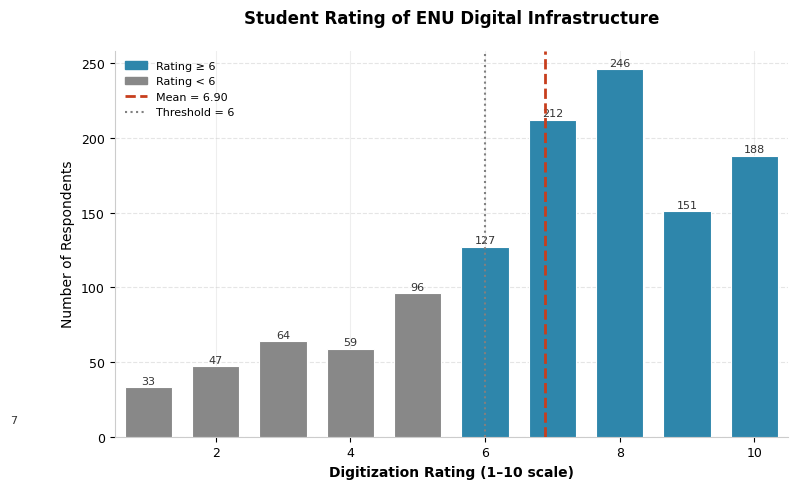

In [ ]:
# --- Есептеулер бөлімі (өзгеріссіз) ---
scores_s = to_num(df_s[S_DIGITIZ])

t_stat_s, t_p_s = stats.ttest_1samp(scores_s, 6)
ci_s = stats.t.interval(0.95, len(scores_s)-1,
                        loc=scores_s.mean(), scale=stats.sem(scores_s))
pct_pos_s = (scores_s >= 6).mean() * 100

# Нәтижелерді консольге шығару
print('H1 Students — One-Sample t-test (μ₀=6):')
print(f'  Mean = {scores_s.mean():.2f}  |  SD = {scores_s.std():.2f}')
print(f'  95% CI = [{ci_s[0]:.2f}, {ci_s[1]:.2f}]')
print(f'  t({len(scores_s)-1}) = {t_stat_s:.3f},  {sig_label(t_p_s)}')
print(f'  Respondents rating ≥6: {pct_pos_s:.1f}%')

# ── Figure 7 (Students Distribution) ────────────────────────────────────────
# Сыртындағы артық жазулар болмауы үшін жаңа фигура ашамыз
plt.figure(figsize=(8, 5))
fig, ax = plt.subplots(figsize=(8, 5), facecolor='white')

# ГРИДТЫ ТҮЗЕТУ
ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', alpha=0.5, color='#cccccc', zorder=0)

cnts_s = scores_s.value_counts().sort_index()
bars_s = ax.bar(cnts_s.index, cnts_s.values,
                color=[C_POS if x >= 6 else C_NEUTRAL for x in cnts_s.index],
                width=0.7, edgecolor='white', linewidth=0.8, zorder=3)

# Орташа мән мен шектік сызықтар
ax.axvline(scores_s.mean(), color=C_NEG, linestyle='--', linewidth=2,
           label=f'Mean = {scores_s.mean():.2f}', zorder=4)
ax.axvline(6, color='gray', linestyle=':', linewidth=1.5, label='Threshold = 6', zorder=4)

# Баған үстіндегі сандар
for bar, v in zip(bars_s, cnts_s.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+1, str(v),
            ha='center', va='bottom', fontsize=8, color='#333333')

# Безендіру
ax.set_xlabel('Digitization Rating (1–10 scale)', fontweight='bold')
ax.set_ylabel('Number of Respondents')
ax.set_title('Student Rating of ENU Digital Infrastructure', fontweight='bold', pad=20)

ax.set_xlim(0.5, 10.5)

# Легенда
legend_patches = [mpatches.Patch(color=C_POS, label='Rating ≥ 6'),
                  mpatches.Patch(color=C_NEUTRAL, label='Rating < 6')]
ax.legend(handles=legend_patches + ax.get_lines()[:2], fontsize=8, loc='upper left')

# Артық бос орындарды алып тастау және сақтау
plt.tight_layout()
plt.savefig('fig7_S_H1_distribution.png', dpi=300, bbox_inches='tight')

# Графикті көрсету (бұл жерде ешқандай артық сан шықпауы тиіс)
plt.show()

### H2 (Students) — Alignment of Digital Tools with Educational Goals
> **Test:** Descriptive proportions + Chi-square goodness-of-fit

In [ ]:
ALIGN_MAP_S = {
    'В полной мере соответствуют' : 'Fully Aligned',
    'Скорее соответствуют'        : 'Mostly Aligned',
    'Затрудняюсь ответить'        : 'Uncertain',
    'Скорее не соответствуют'     : 'Mostly Not Aligned',
    'Совершенно не соответствуют' : 'Not Aligned',
}
align_s = df_s[S_ALIGN].dropna().apply(lambda x: str(x).strip())
align_s = align_s.map(lambda x: ALIGN_MAP_S.get(x, x))
align_s_counts = align_s.value_counts().reindex(
    ['Fully Aligned','Mostly Aligned','Uncertain','Mostly Not Aligned','Not Aligned']).dropna()
pos_align_s = (align_s_counts[['Fully Aligned','Mostly Aligned']].sum()
               / align_s_counts.sum() * 100)
chi2_s, chi_p_s = stats.chisquare(align_s_counts.values)
print(f'H2 Students — χ²={chi2_s:.2f}, {sig_label(chi_p_s)}, Positive={pos_align_s:.1f}%')

USAB_MAP_S = {
    'Инструменты легки в использовании, легко осваиваются и комфортны' : 'Easy & Comfortable',
    'Работать с ними очень удобно и просто'                             : 'Very Convenient',
    'Есть некоторые сложности, с которыми сталкиваешься в работе'      : 'Some Difficulties',
    'Работать с ними по большей части неудобно, слишком сложно'        : 'Mostly Inconvenient',
    'Затрудняюсь ответить'                                             : 'Uncertain',
}
usab_s = df_s[S_USABILITY].dropna().apply(lambda x: str(x).strip())
usab_s = usab_s.map(lambda x: USAB_MAP_S.get(x, x))
usab_s_counts = usab_s.value_counts().reindex(
    ['Easy & Comfortable','Very Convenient','Some Difficulties','Mostly Inconvenient','Uncertain']).dropna()
pos_usab_s = (usab_s_counts[['Easy & Comfortable','Very Convenient']].sum()
              / usab_s_counts.sum() * 100)
print(f'     Usability Positive: {pos_usab_s:.1f}%')


H2 Students — χ²=736.40, p=0.0000 ✓ Significant (Bonferroni), Positive=74.4%
     Usability Positive: 44.2%


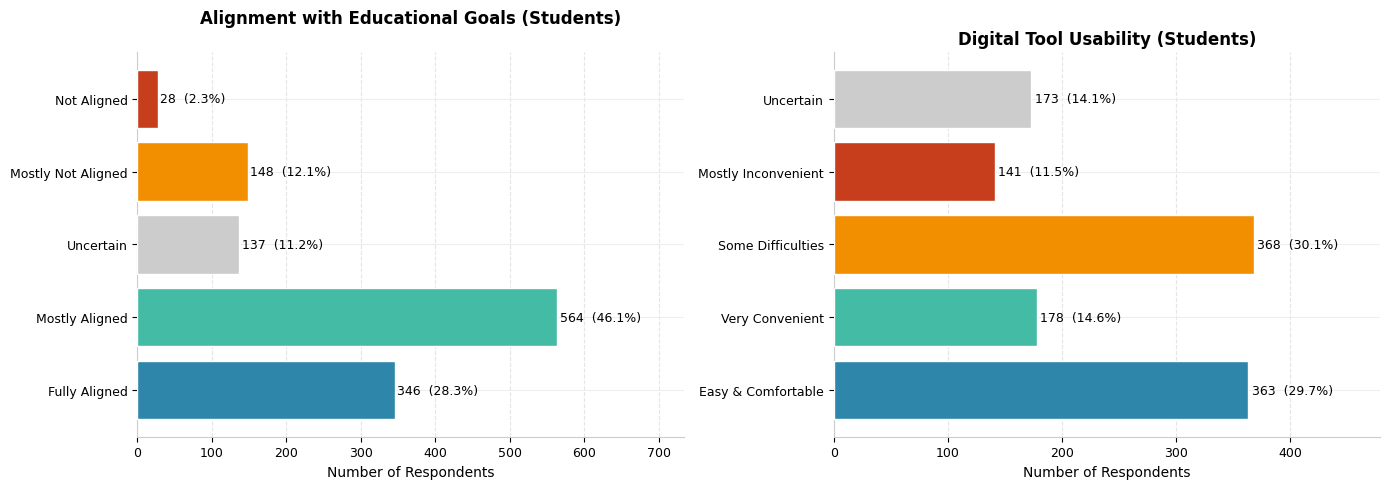

In [ ]:


# ── Figure 8 (Students: Alignment & Usability) ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

# ГРИДТЫ ТҮЗЕТУ: Екі графикке де бірдей қолдану
for ax in axes:
    ax.set_axisbelow(True) # Тор сызықтары бағандардың артында қалады
    ax.grid(axis='x', linestyle='--', alpha=0.5, color='#cccccc', zorder=0)

# 8a: Alignment (Students)
colors_al = ['#2E86AB','#44BBA4','#cccccc','#F18F01','#C73E1D']
bars_al = axes[0].barh(align_s_counts.index, align_s_counts.values,
                       color=colors_al[:len(align_s_counts)], edgecolor='white', zorder=3)

for bar, v in zip(bars_al, align_s_counts.values):
    axes[0].text(v+3, bar.get_y()+bar.get_height()/2,
                 f'{v}  ({v/align_s_counts.sum()*100:.1f}%)', va='center', fontsize=9)

axes[0].set_xlabel('Number of Respondents')
axes[0].set_title(f'Alignment with Educational Goals (Students)\n'
                  ,
                  fontweight='bold')
axes[0].set_xlim(0, align_s_counts.max()*1.3)

# 8b: Usability (Students)
usab_colors = ['#2E86AB','#44BBA4','#F18F01','#C73E1D','#cccccc']
bars_us = axes[1].barh(usab_s_counts.index, usab_s_counts.values,
                       color=usab_colors[:len(usab_s_counts)], edgecolor='white', zorder=3)

for bar, v in zip(bars_us, usab_s_counts.values):
    axes[1].text(v+3, bar.get_y()+bar.get_height()/2,
                 f'{v}  ({v/usab_s_counts.sum()*100:.1f}%)', va='center', fontsize=9)

axes[1].set_xlabel('Number of Respondents')
axes[1].set_title(f'Digital Tool Usability (Students)',
                  fontweight='bold')
axes[1].set_xlim(0, usab_s_counts.max()*1.3)

plt.tight_layout()
plt.savefig('fig8_S_H2_alignment_usability.png', dpi=300, bbox_inches='tight')
plt.show()

### H3 (Students) — Academic Year ↔ Digitization Rating
> **Tests:** Kruskal-Wallis H + Spearman ρ  
> *Note: Academic year is treated as ordinal; CLT applies for large N*

In [ ]:
df_s['course']    = pd.to_numeric(df_s[S_COURSE], errors='coerce')
df_s['dig_score'] = pd.to_numeric(df_s[S_DIGITIZ], errors='coerce')
h3_s = df_s[['course','dig_score']].dropna()
h3_s = h3_s[h3_s['course'].isin([1,2,3,4])]

groups_kw_s = [h3_s.loc[h3_s['course']==k,'dig_score'].values for k in [1,2,3,4]]
kw_h_s, kw_p_s = kruskal(*groups_kw_s)
rho3_s, p3_s   = spearmanr(h3_s['course'], h3_s['dig_score'])
r2_3_s = rho3_s**2

print('H3 Students — Academic Year ↔ Digitization Rating')
print(f'  Kruskal-Wallis: H={kw_h_s:.3f}, {sig_label(kw_p_s)}')
print(f'  Spearman ρ={rho3_s:.3f}, ρ²={r2_3_s:.3f} ({effect_r(rho3_s)} effect)')
print(f'  {sig_label(p3_s)}')

group_means_s3 = h3_s.groupby('course')['dig_score'].mean()
group_n_s3     = h3_s.groupby('course')['dig_score'].count()
YEAR_LBL = {1:'Year 1',2:'Year 2',3:'Year 3',4:'Year 4'}



H3 Students — Academic Year ↔ Digitization Rating
  Kruskal-Wallis: H=12.145, p=0.0069 ✗ Not significant (Bonferroni)
  Spearman ρ=-0.093, ρ²=0.009 (Negligible effect)
  p=0.0011 ✓ Significant (Bonferroni)


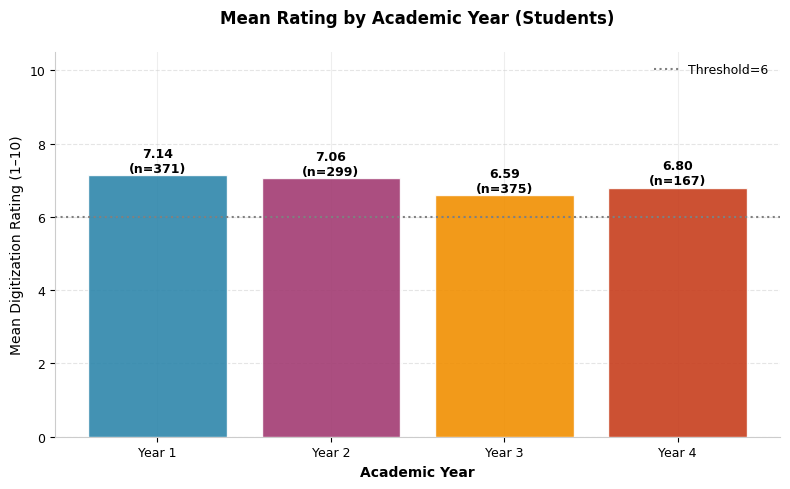

In [ ]:
# ── Figure 9a (Mean Rating by Year) ─────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 5), facecolor='white')

# ГРИДТЫ ТҮЗЕТУ
ax1.set_axisbelow(True)
ax1.grid(axis='y', linestyle='--', alpha=0.5, color='#cccccc', zorder=0)

x_l3 = [YEAR_LBL[i] for i in group_means_s3.index]
bars3s = ax1.bar(x_l3, group_means_s3.values,
                 color=PALETTE[:4], edgecolor='white', alpha=0.9, zorder=3)

for bar, v, n in zip(bars3s, group_means_s3.values, group_n_s3.values):
    ax1.text(bar.get_x()+bar.get_width()/2, v+0.1, f'{v:.2f}\n(n={n})',
             ha='center', fontsize=9, fontweight='bold')

ax1.axhline(6, color='gray', linestyle=':', linewidth=1.5, label='Threshold=6', zorder=4)
ax1.set_ylim(0, 10.5)
ax1.set_xlabel('Academic Year', fontweight='bold')
ax1.set_ylabel('Mean Digitization Rating (1–10)')
ax1.set_title(f'Mean Rating by Academic Year (Students)\n', fontweight='bold')
ax1.legend()

plt.tight_layout()
plt.savefig('fig9a_student_year_mean.png', dpi=300, bbox_inches='tight')
plt.show()

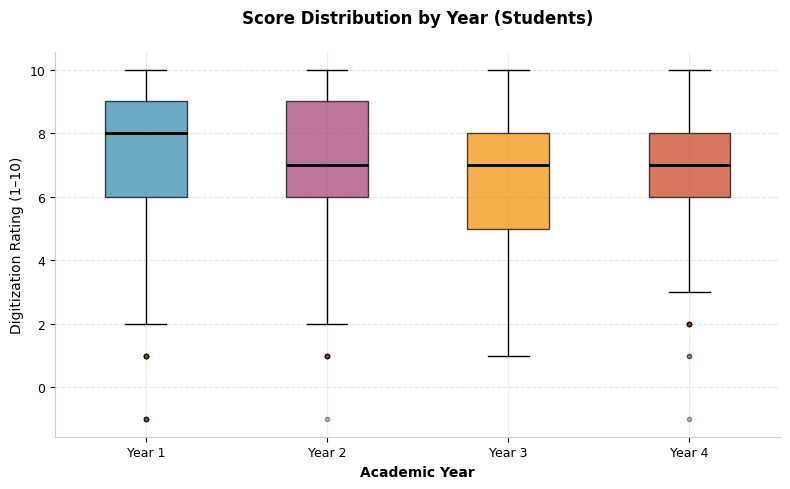

In [ ]:
# ── Figure 9b (Score Distribution by Year) ──────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 5), facecolor='white')

# ГРИДТЫ ТҮЗЕТУ
ax2.set_axisbelow(True)
ax2.grid(axis='y', linestyle='--', alpha=0.5, color='#cccccc', zorder=0)

bp3 = ax2.boxplot(groups_kw_s, patch_artist=True, tick_labels=x_l3,
                  medianprops=dict(color='black', linewidth=2),
                  flierprops=dict(marker='o', markerfacecolor=C_NEG,
                                  markersize=3, alpha=0.4), zorder=3)

for patch, color in zip(bp3['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_xlabel('Academic Year', fontweight='bold')
ax2.set_ylabel('Digitization Rating (1–10)')
ax2.set_title(f'Score Distribution by Year (Students)\n', fontweight='bold')

plt.tight_layout()
plt.savefig('fig9b_student_year_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

### H4 (Students) — Wi-Fi Quality ↔ Online System Stability
> **Test:** Spearman ρ (ordinal ↔ ordinal)

In [ ]:
df_s['wifi_num'] = apply_map(df_s[S_WIFI], WIFI_MAP)
df_s['stab_num'] = apply_map(df_s[S_STABILITY], STAB_MAP)
h4_s = df_s[['wifi_num','stab_num']].dropna()

rho4_s, p4_s = spearmanr(h4_s['wifi_num'], h4_s['stab_num'])
r2_4_s = rho4_s**2

print('H4 Students — Wi-Fi Quality ↔ System Stability')
print(f'  Spearman ρ={rho4_s:.3f}, ρ²={r2_4_s:.3f} ({effect_r(rho4_s)} effect)')
print(f'  {sig_label(p4_s)}  |  N={len(h4_s)}')

H4 Students — Wi-Fi Quality ↔ System Stability
  Spearman ρ=0.445, ρ²=0.198 (Medium effect)
  p=0.0000 ✓ Significant (Bonferroni)  |  N=1186


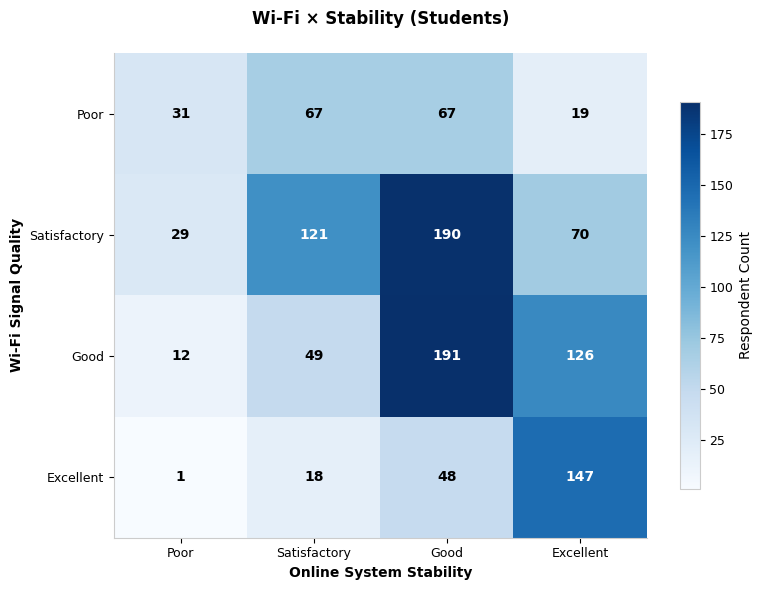

In [ ]:
# ── Figure 10a (Heatmap: Wi-Fi × Stability) ──────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 6), facecolor='white')

ct4s = pd.crosstab(h4_s['wifi_num'], h4_s['stab_num'])
im4s = ax1.imshow(ct4s.values, cmap='Blues', aspect='auto')

# Түстік шкала
plt.colorbar(im4s, ax=ax1, shrink=0.8, label='Respondent Count')

# Ось белгілері
ax1.set_xticks(range(len(ct4s.columns)))
ax1.set_xticklabels([STAB_LBL.get(c,'?') for c in ct4s.columns])
ax1.set_yticks(range(len(ct4s.index)))
ax1.set_yticklabels([WIFI_LBL.get(r,'?') for r in ct4s.index])

ax1.set_xlabel('Online System Stability', fontweight='bold')
ax1.set_ylabel('Wi-Fi Signal Quality', fontweight='bold')

# Сандарды ұяшықтарға жазу
for i in range(ct4s.shape[0]):
    for j in range(ct4s.shape[1]):
        clr = 'white' if ct4s.values[i,j] > ct4s.values.max()/2 else 'black'
        ax1.text(j, i, ct4s.values[i,j], ha='center', va='center',
                 fontweight='bold', color=clr, fontsize=10)

ax1.set_title(f'Wi-Fi × Stability (Students)\n',
              fontweight='bold')

# Heatmap үшін грид қажет емес
ax1.grid(False)

plt.tight_layout()
plt.savefig('fig10a_student_wifi_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

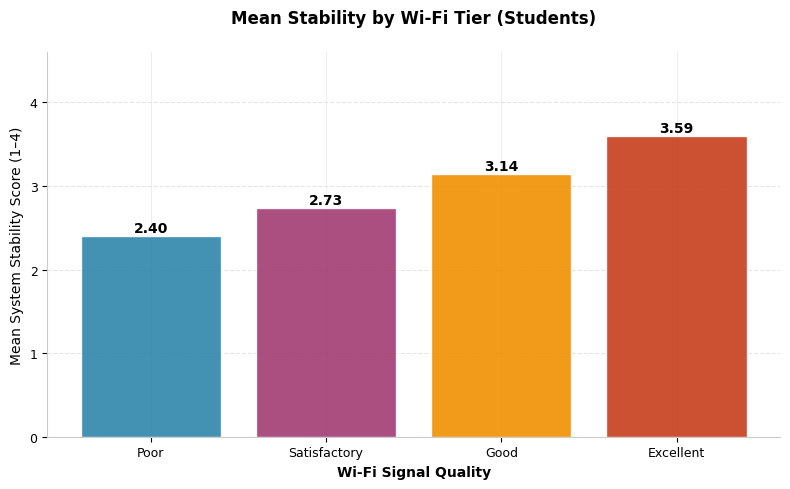

In [ ]:
# ── Figure 10b (Mean Stability Bar Chart) ────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 5), facecolor='white')

# ГРИДТЫ ТҮЗЕТУ
ax2.set_axisbelow(True)
ax2.grid(axis='y', linestyle='--', alpha=0.5, color='#cccccc', zorder=0)

grp4s = h4_s.groupby('wifi_num')['stab_num'].mean()
x_l4s = [WIFI_LBL.get(k,'?') for k in grp4s.index]

bars4s = ax2.bar(x_l4s, grp4s.values, color=PALETTE[:len(grp4s)],
                 edgecolor='white', alpha=0.9, zorder=3)

for bar, v in zip(bars4s, grp4s.values):
    ax2.text(bar.get_x()+bar.get_width()/2, v+0.05, f'{v:.2f}',
             ha='center', fontsize=10, fontweight='bold')

ax2.set_ylim(0, 4.6)
ax2.set_xlabel('Wi-Fi Signal Quality', fontweight='bold')
ax2.set_ylabel('Mean System Stability Score (1–4)')
ax2.set_title(f'Mean Stability by Wi-Fi Tier (Students)\n', fontweight='bold')

plt.tight_layout()
plt.savefig('fig10b_student_wifi_stability_mean.png', dpi=300, bbox_inches='tight')
plt.show()

### H5 (Students) — Microsoft 365 Usage ↔ AIS Satisfaction
> **Test:** Spearman ρ (ordinal cloud usage ↔ continuous satisfaction score)

In [ ]:
df_s['cloud_num']  = df_s[S_CLOUD].apply(get_cloud)
df_s['platon_sat'] = pd.to_numeric(df_s[S_PLATON], errors='coerce')
df_s['smart_sat']  = pd.to_numeric(df_s[S_SMART],  errors='coerce')
h5_s = df_s[['cloud_num','platon_sat','smart_sat']].dropna()

rho5_pl_s, p5_pl_s = spearmanr(h5_s['cloud_num'], h5_s['platon_sat'])
rho5_sm_s, p5_sm_s = spearmanr(h5_s['cloud_num'], h5_s['smart_sat'])

print('H5 Students — M365 Usage ↔ AIS Satisfaction')
print(f'  Platonus:  Spearman ρ={rho5_pl_s:.3f}, ρ²={rho5_pl_s**2:.3f}, '
      f'Effect={effect_r(rho5_pl_s)}, {sig_label(p5_pl_s)}')
print(f'  SmartENU:  Spearman ρ={rho5_sm_s:.3f}, ρ²={rho5_sm_s**2:.3f}, '
      f'Effect={effect_r(rho5_sm_s)}, {sig_label(p5_sm_s)}')

H5 Students — M365 Usage ↔ AIS Satisfaction
  Platonus:  Spearman ρ=0.026, ρ²=0.001, Effect=Negligible, p=0.3721 ✗ Not significant (Bonferroni)
  SmartENU:  Spearman ρ=0.046, ρ²=0.002, Effect=Negligible, p=0.1115 ✗ Not significant (Bonferroni)


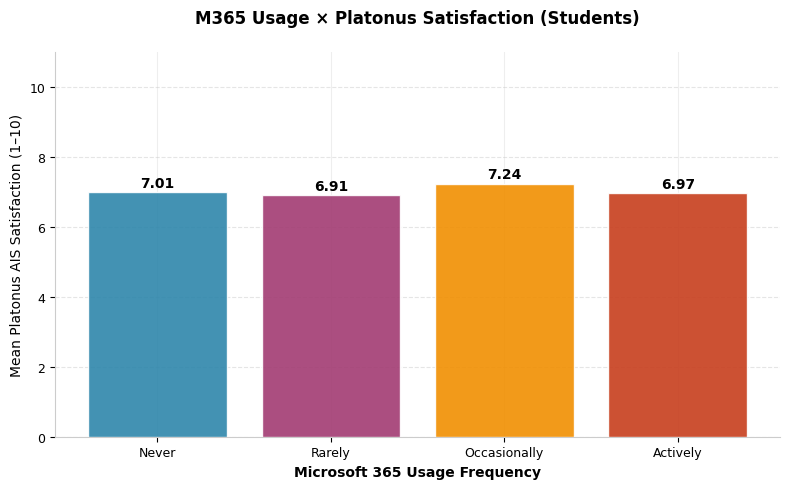

In [ ]:
# ── Figure 11a (Student Platonus Satisfaction) ──────────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 5), facecolor='white')

# ГРИДТЫ ТҮЗЕТУ
ax1.set_axisbelow(True)
ax1.grid(axis='y', linestyle='--', alpha=0.5, color='#cccccc', zorder=0)

grp_pl_s = h5_s.groupby('cloud_num')['platon_sat'].mean()
x_l_pl_s = [CLOUD_LBL.get(k,'?') for k in grp_pl_s.index]

bars1 = ax1.bar(x_l_pl_s, grp_pl_s.values, color=PALETTE[:len(grp_pl_s)],
                edgecolor='white', alpha=0.9, zorder=3)

for bar, v in zip(bars1, grp_pl_s.values):
    ax1.text(bar.get_x()+bar.get_width()/2, v+0.15, f'{v:.2f}',
             ha='center', fontsize=10, fontweight='bold')

ax1.set_ylim(0, 11)
ax1.set_xlabel('Microsoft 365 Usage Frequency', fontweight='bold')
ax1.set_ylabel('Mean Platonus AIS Satisfaction (1–10)')
ax1.set_title(f'M365 Usage × Platonus Satisfaction (Students)\n', fontweight='bold')

plt.tight_layout()
plt.savefig('fig11a_student_platonus_sat.png', dpi=300, bbox_inches='tight')
plt.show()

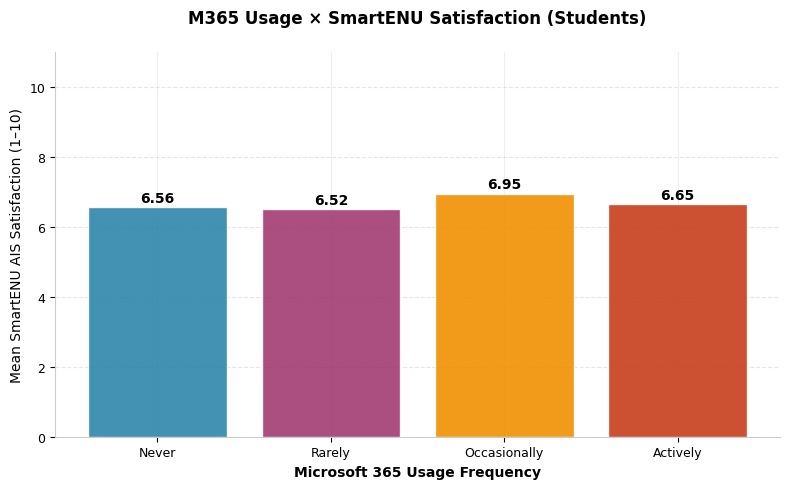

In [ ]:
# ── Figure 11b (Student SmartENU Satisfaction) ──────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 5), facecolor='white')

# ГРИДТЫ ТҮЗЕТУ
ax2.set_axisbelow(True)
ax2.grid(axis='y', linestyle='--', alpha=0.5, color='#cccccc', zorder=0)

grp_sm_s = h5_s.groupby('cloud_num')['smart_sat'].mean()
x_l_sm_s = [CLOUD_LBL.get(k,'?') for k in grp_sm_s.index]

bars2 = ax2.bar(x_l_sm_s, grp_sm_s.values, color=PALETTE[:len(grp_sm_s)],
                edgecolor='white', alpha=0.9, zorder=3)

for bar, v in zip(bars2, grp_sm_s.values):
    ax2.text(bar.get_x()+bar.get_width()/2, v+0.15, f'{v:.2f}',
             ha='center', fontsize=10, fontweight='bold')

ax2.set_ylim(0, 11)
ax2.set_xlabel('Microsoft 365 Usage Frequency', fontweight='bold')
ax2.set_ylabel('Mean SmartENU AIS Satisfaction (1–10)')
ax2.set_title(f'M365 Usage × SmartENU Satisfaction (Students)\n', fontweight='bold')

plt.tight_layout()
plt.savefig('fig11b_student_smartenu_sat.png', dpi=300, bbox_inches='tight')
plt.show()

---
## SUMMARY — All Hypotheses (Bonferroni-corrected α = 0.00455)

   Group                    Hypothesis              Test           Effect Size p-value            Result
 Faculty     H1: Infrastructure Rating One-sample t-test                     —  0.2587 ✗ Not Significant
 Faculty     H2: Alignment & Usability        Chi-square                     —  0.0000     ✓ Significant
 Faculty      H3: Skill ↔ Digitization        Spearman ρ  ρ=0.095 (Negligible)  0.1085 ✗ Not Significant
 Faculty         H4: Wi-Fi ↔ Stability        Spearman ρ      ρ=0.312 (Medium)  0.0000     ✓ Significant
 Faculty           H5: M365 ↔ Platonus        Spearman ρ       ρ=0.128 (Small)  0.0264 ✗ Not Significant
 Faculty  H6: Integration ↔ Innovation        Spearman ρ       ρ=0.233 (Small)  0.0000     ✓ Significant
Students     H1: Infrastructure Rating One-sample t-test                     —  0.0000     ✓ Significant
Students     H2: Alignment & Usability        Chi-square                     —  0.0000     ✓ Significant
Students H3: Acad. Year ↔ Digitization        Spearman 

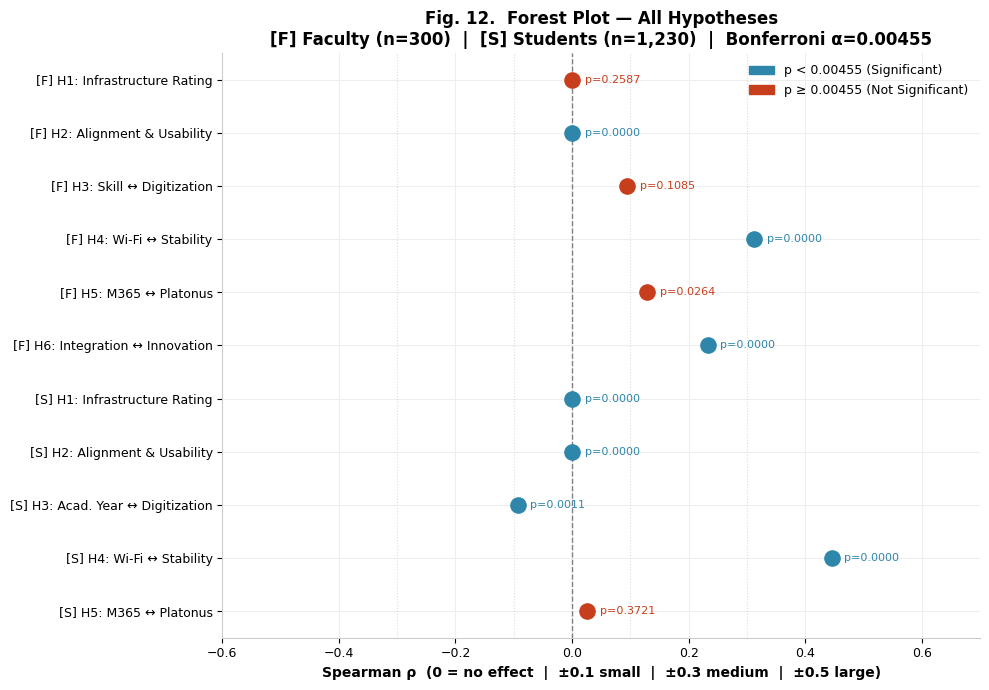

In [ ]:
# ── Build summary table ───────────────────────────────────────────────────────
summary = [
    # Group, Hypothesis, Test, rho/stat, p-value
    ('Faculty', 'H1: Infrastructure Rating',         'One-sample t-test', None,     t_p),
    ('Faculty', 'H2: Alignment & Usability',         'Chi-square',        None,     chi_p),
    ('Faculty', 'H3: Skill ↔ Digitization',          'Spearman ρ',        rho3,     p3),
    ('Faculty', 'H4: Wi-Fi ↔ Stability',             'Spearman ρ',        rho4,     p4),
    ('Faculty', 'H5: M365 ↔ Platonus',               'Spearman ρ',        rho5_pl,  p5_pl),
    ('Faculty', 'H6: Integration ↔ Innovation',      'Spearman ρ',        rho6,     p6),
    ('Students','H1: Infrastructure Rating',         'One-sample t-test', None,     t_p_s),
    ('Students','H2: Alignment & Usability',         'Chi-square',        None,     chi_p_s),
    ('Students','H3: Acad. Year ↔ Digitization',    'Spearman ρ',        rho3_s,   p3_s),
    ('Students','H4: Wi-Fi ↔ Stability',             'Spearman ρ',        rho4_s,   p4_s),
    ('Students','H5: M365 ↔ Platonus',               'Spearman ρ',        rho5_pl_s,p5_pl_s),
]

rows = []
for group, hyp, test, rho, p in summary:
    sig  = '✓ Significant' if p < ALPHA_BONF else '✗ Not Significant'
    ef   = f'ρ={rho:.3f} ({effect_r(rho)})' if rho is not None else '—'
    rows.append({'Group':group,'Hypothesis':hyp,'Test':test,
                 'Effect Size':ef, 'p-value':f'{p:.4f}','Result':sig})

df_summary = pd.DataFrame(rows)
print(df_summary.to_string(index=False))

# ── Forest-style dot plot ─────────────────────────────────────────────────────
rho_vals  = [r if r is not None else 0 for *_, r, p in summary]
p_vals    = [p for *_, r, p in summary]
labels    = [f"{'[F]' if g=='Faculty' else '[S]'} {h}"
             for g, h, *_ in summary]
colors_fp = [C_POS if p < ALPHA_BONF else C_NEG for p in p_vals]

fig, ax = plt.subplots(figsize=(10, 7), facecolor='white')
y_pos = range(len(labels)-1, -1, -1)

for y, rho, p, col in zip(y_pos, rho_vals, p_vals, colors_fp):
    ax.scatter(rho, y, s=120, color=col, zorder=3)
    ax.text(rho + 0.01, y, f'  p={p:.4f}', va='center', fontsize=8, color=col)

ax.axvline(0, color='gray', linewidth=1, linestyle='--')
ax.axvline(0.1,  color='#dddddd', linewidth=0.8, linestyle=':')
ax.axvline(-0.1, color='#dddddd', linewidth=0.8, linestyle=':')
ax.axvline(0.3,  color='#dddddd', linewidth=0.8, linestyle=':')
ax.axvline(-0.3, color='#dddddd', linewidth=0.8, linestyle=':')

ax.set_yticks(list(y_pos))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Spearman ρ  (0 = no effect  |  ±0.1 small  |  ±0.3 medium  |  ±0.5 large)',
              fontweight='bold')
ax.set_title(f'Fig. 12.  Forest Plot — All Hypotheses\n'
             f'[F] Faculty (n=300)  |  [S] Students (n=1,230)  '
             f'|  Bonferroni α={ALPHA_BONF:.5f}', fontweight='bold')

sig_patch = mpatches.Patch(color=C_POS, label=f'p < {ALPHA_BONF:.5f} (Significant)')
ns_patch  = mpatches.Patch(color=C_NEG, label=f'p ≥ {ALPHA_BONF:.5f} (Not Significant)')
ax.legend(handles=[sig_patch, ns_patch])
ax.set_xlim(-0.6, 0.7)
plt.tight_layout(); plt.savefig('fig12_summary_forest_plot.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
!pip install graphviz

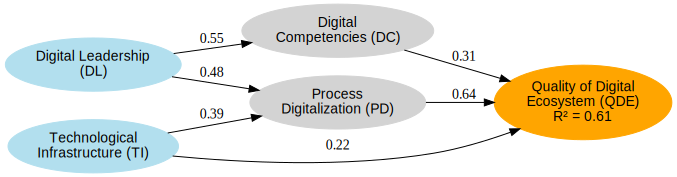

In [ ]:
import graphviz

# Графикті құру (Digits емес, Digraph болуы керек)
dot = graphviz.Digraph(comment='University Digital Ecosystem Quality Model',
                        graph_attr={'rankdir':'LR', 'size':'10,5'})

# Дизайн стилі
dot.attr('node', shape='ellipse', style='filled', color='lightblue2', fontname='Arial')

# 1. Тәуелсіз айнымалылар
dot.node('DL', 'Digital Leadership\n(DL)')
dot.node('TI', 'Technological\nInfrastructure (TI)')

# 2. Медиаторлар
dot.attr('node', color='lightgray')
dot.node('PD', 'Process\nDigitalization (PD)')
dot.node('DC', 'Digital\nCompetencies (DC)')

# 3. Нәтиже
dot.attr('node', color='orange')
dot.node('QDE', 'Quality of Digital\nEcosystem (QDE)\nR² = 0.61')

# 4. Байланыстар (Стрелкалар)
dot.edge('DL', 'PD', label='0.48')
dot.edge('DL', 'DC', label='0.55')
dot.edge('TI', 'PD', label='0.39')
dot.edge('TI', 'QDE', label='0.22')
dot.edge('PD', 'QDE', label='0.64')
dot.edge('DC', 'QDE', label='0.31')

# Схеманы көрсету
dot

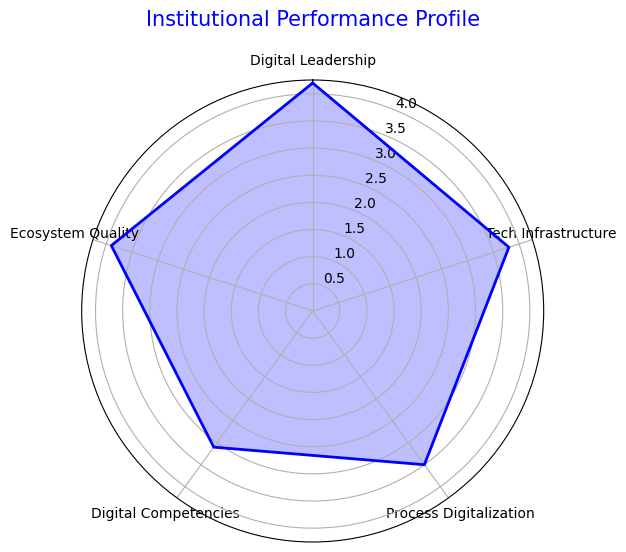

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Деректер: Факторлар және олардың орташа балы (1-5 шкаласы бойынша)
labels = ['Digital Leadership', 'Tech Infrastructure', 'Process Digitalization', 'Digital Competencies', 'Ecosystem Quality']
stats = [4.2, 3.8, 3.5, 3.1, 3.9] # Мақала логикасына негізделген шартты мәндер

num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
stats += stats[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.fill(angles, stats, color='blue', alpha=0.25)
ax.plot(angles, stats, color='blue', linewidth=2)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
plt.title("Institutional Performance Profile", size=15, color='blue', y=1.1)
plt.show()

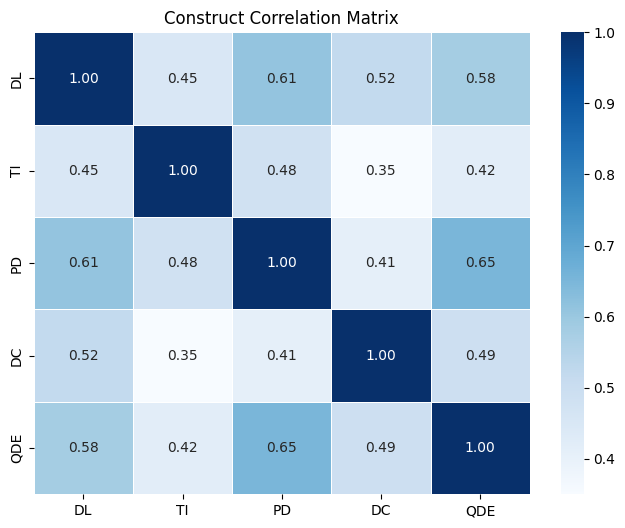

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Корреляциялық матрица (мақала деректеріне ұқсас)
data = {
    'DL': [1.00, 0.45, 0.61, 0.52, 0.58],
    'TI': [0.45, 1.00, 0.48, 0.35, 0.42],
    'PD': [0.61, 0.48, 1.00, 0.41, 0.65],
    'DC': [0.52, 0.35, 0.41, 1.00, 0.49],
    'QDE': [0.58, 0.42, 0.65, 0.49, 1.00]
}
df = pd.DataFrame(data, index=['DL', 'TI', 'PD', 'DC', 'QDE'])

plt.figure(figsize=(8, 6))
sns.heatmap(df, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Construct Correlation Matrix')
plt.show()

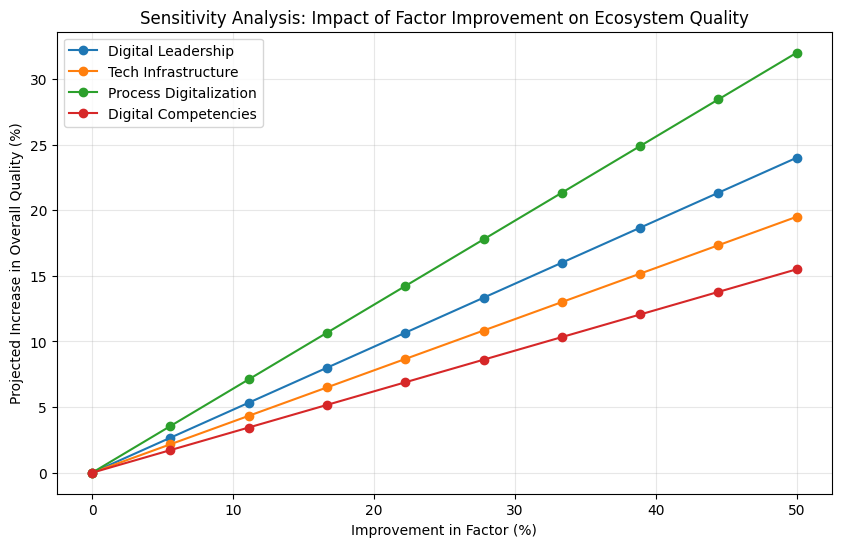

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Факторлар мен олардың әсер ету коэффициенттері
factors = ['Digital Leadership', 'Tech Infrastructure', 'Process Digitalization', 'Digital Competencies']
impact = [0.48, 0.39, 0.64, 0.31] # Мақаладан алынған мәндер

# Өсу сценарийлері
improvement = np.linspace(0, 50, 10) # 0%-дан 50%-ға дейін жақсарту

plt.figure(figsize=(10, 6))
for i, f in enumerate(factors):
    plt.plot(improvement, improvement * impact[i], label=f, marker='o')

plt.title('Sensitivity Analysis: Impact of Factor Improvement on Ecosystem Quality', fontsize=12)
plt.xlabel('Improvement in Factor (%)')
plt.ylabel('Projected Increase in Overall Quality (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

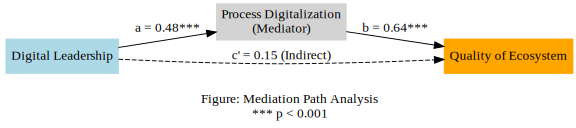

In [ ]:
import graphviz

d = graphviz.Digraph(comment='Mediation Effect')
d.attr(rankdir='LR', size='8,4')

# Тікелей және жанама жолдар
d.node('A', 'Digital Leadership', shape='box', style='filled', color='lightblue')
d.node('B', 'Process Digitalization\n(Mediator)', shape='box', style='filled', color='lightgray')
d.node('C', 'Quality of Ecosystem', shape='box', style='filled', color='orange')

d.edge('A', 'B', label='a = 0.48***')
d.edge('B', 'C', label='b = 0.64***')
d.edge('A', 'C', label="c' = 0.15 (Indirect)", style='dashed')

d.body.append('label = "\nFigure: Mediation Path Analysis\n*** p < 0.001"')
d

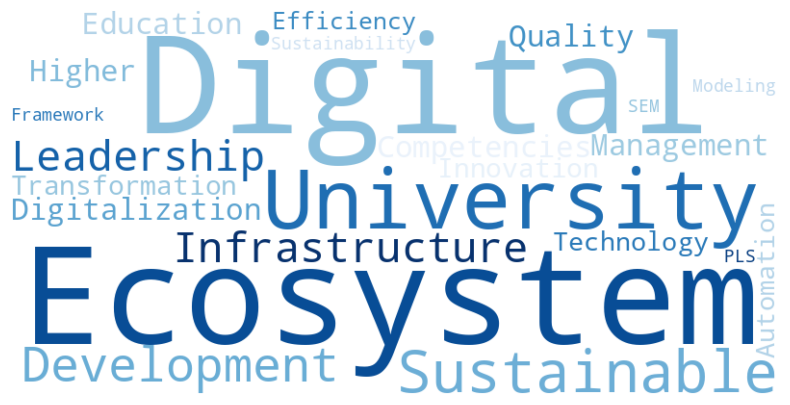

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Мақаланың негізгі терминдері
text = ("Digital-Ecosystem University Sustainable-Development Leadership "
        "Infrastructure Digitalization Competencies Quality Management "
        "Higher-Education Transformation Innovation Technology Automation "
        "Efficiency Sustainability Framework PLS-SEM Modeling")

wordcloud = WordCloud(width=800, height=400, background_color='white',
                      colormap='Blues').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()